# Asset Maintenance & Operations Performance Analysis

Portfolio case study using the Microsoft Azure Predictive Maintenance benchmark dataset. The original concept included cost and downtime KPIs, but the public source does not contain those fields. They are intentionally not fabricated.


## Business questions
- How much maintenance is proactive vs reactive?
- Which machines and models experience the most failures?
- Which components fail most often?
- How do maintenance and failure events change over time?
- Is machine age associated with observed failure frequency?
- Which assets deserve closer operational attention based on recorded events?


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
IMG = ROOT / "images"
pd.set_option("display.max_columns", 50)


## 1. Load raw source tables


In [2]:
telemetry = pd.read_csv(RAW / "PdM_telemetry.csv")
errors = pd.read_csv(RAW / "PdM_errors.csv")
maintenance = pd.read_csv(RAW / "PdM_maint.csv")
failures = pd.read_csv(RAW / "PdM_failures.csv")
machines = pd.read_csv(RAW / "PdM_machines.csv")

for name, df in {"telemetry":telemetry,"errors":errors,"maintenance":maintenance,"failures":failures,"machines":machines}.items():
    print(name, df.shape)
    display(df.head(3))


telemetry (876100, 6)


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847


errors (3919, 3)


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5


maintenance (3286, 3)


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3


failures (761, 3)


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2


machines (100, 3)


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8


## 2. Data quality audit
We inspect missing values, duplicates, types, categories and referential integrity. We do not delete outliers automatically because unusual sensor readings can be operationally meaningful.


In [3]:
tables = {"telemetry":telemetry,"errors":errors,"maintenance":maintenance,"failures":failures,"machines":machines}
audit=[]
for name, df in tables.items():
    audit.append({"table":name,"rows":len(df),"columns":len(df.columns),"duplicates":df.duplicated().sum(),"missing_cells":df.isna().sum().sum()})
display(pd.DataFrame(audit))
for name, df in tables.items():
    print("\n", name)
    display(df.dtypes.to_frame("dtype"))


,table,rows,columns,duplicates,missing_cells
0,telemetry,876100,6,0,0
1,errors,3919,3,0,0
2,maintenance,3286,3,0,0
3,failures,761,3,0,0
4,machines,100,3,0,0



 telemetry


,dtype
datetime,str
machineID,int64
volt,float64
rotate,float64
pressure,float64
vibration,float64



 errors


,dtype
datetime,str
machineID,int64
errorID,str


...

,dtype
datetime,str
machineID,int64
comp,str



 failures


,dtype
datetime,str
machineID,int64
failure,str



 machines


,dtype
machineID,int64
model,str
age,int64


In [4]:
for name in ["telemetry","errors","maintenance","failures"]:
    tables[name]["datetime"] = pd.to_datetime(tables[name]["datetime"], errors="coerce")
    print(name, "invalid datetime:", tables[name]["datetime"].isna().sum())

valid_ids=set(machines["machineID"])
for name in ["telemetry","errors","maintenance","failures"]:
    print(name, "orphan machine IDs:", (~tables[name]["machineID"].isin(valid_ids)).sum())


telemetry invalid datetime: 0
errors invalid datetime: 0
maintenance invalid datetime: 0
failures invalid datetime: 0
telemetry orphan machine IDs: 0
errors orphan machine IDs: 0
maintenance orphan machine IDs: 0
failures orphan machine IDs: 0


## 3. Clean and derive maintenance type
The source documentation states that failures are component replacements caused by breakdowns and are a subset of maintenance history. Therefore, an exact machine + timestamp + component match is classified as **Reactive**; other maintenance replacements are **Proactive**.


In [5]:
maintenance = maintenance.drop_duplicates().copy()
failures = failures.drop_duplicates().copy()
maintenance["comp"] = maintenance["comp"].str.strip()
failures["failure"] = failures["failure"].str.strip()

reactive = failures.rename(columns={"failure":"comp"})[["datetime","machineID","comp"]].drop_duplicates().assign(is_failure=1)
maintenance = maintenance.merge(reactive, on=["datetime","machineID","comp"], how="left")
maintenance["maintenance_type"] = np.where(maintenance["is_failure"].eq(1), "Reactive", "Proactive")
maintenance.drop(columns="is_failure", inplace=True)
maintenance["maintenance_type"].value_counts()


maintenance_type
Proactive    2543
Reactive      743
Name: count, dtype: int64

## 4. KPI overview


In [6]:
kpis = {
    "Total maintenance events": len(maintenance),
    "Total failure events": len(failures),
    "Unique assets": machines["machineID"].nunique(),
    "Reactive maintenance rate": (maintenance["maintenance_type"].eq("Reactive").mean()),
    "Proactive maintenance rate": (maintenance["maintenance_type"].eq("Proactive").mean()),
    "Failures per asset": len(failures) / machines["machineID"].nunique(),
}
pd.Series(kpis)


Total maintenance events      3286.000000
Total failure events           761.000000
Unique assets                  100.000000
Reactive maintenance rate        0.226111
Proactive maintenance rate       0.773889
Failures per asset               7.610000
dtype: float64

## 5. Maintenance and failure composition


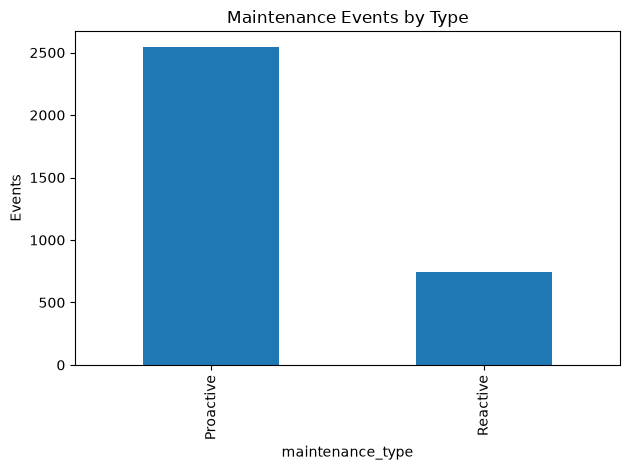

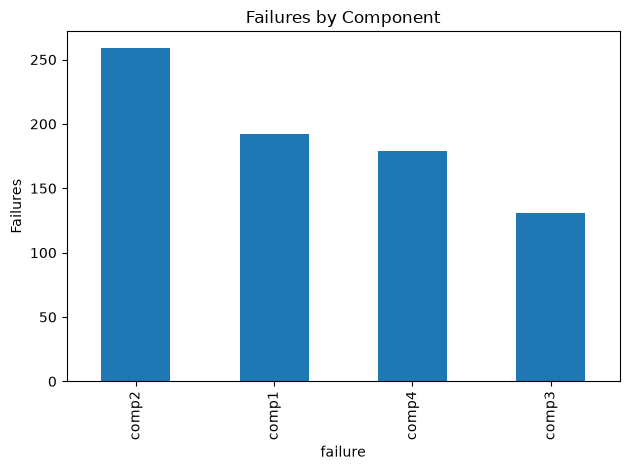

In [7]:
maintenance["maintenance_type"].value_counts().plot(kind="bar", title="Maintenance Events by Type")
plt.ylabel("Events"); plt.tight_layout(); plt.show()

failures["failure"].value_counts().plot(kind="bar", title="Failures by Component")
plt.ylabel("Failures"); plt.tight_layout(); plt.show()


## 6. Asset-level performance


,machineID,model,age,failure_events,maintenance_events
98,99,model1,14,19,34
97,98,model2,20,16,37
16,17,model1,14,15,32
21,22,model1,14,15,33
36,37,model1,16,14,35
82,83,model4,18,14,34
12,13,model1,15,13,33
15,16,model1,3,13,29
19,20,model2,16,13,33
70,71,model2,18,13,33


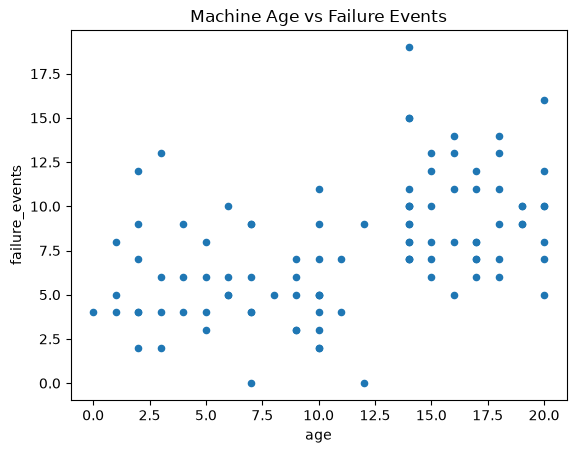

In [8]:
failure_counts = failures.groupby("machineID").size().rename("failure_events")
maint_counts = maintenance.groupby("machineID").size().rename("maintenance_events")
asset = machines.merge(failure_counts, on="machineID", how="left").merge(maint_counts, on="machineID", how="left").fillna({"failure_events":0,"maintenance_events":0})
asset[["failure_events","maintenance_events"]] = asset[["failure_events","maintenance_events"]].astype(int)
display(asset.nlargest(10,"failure_events"))
asset.plot.scatter(x="age", y="failure_events", title="Machine Age vs Failure Events")
plt.show()


## 7. Monthly trend


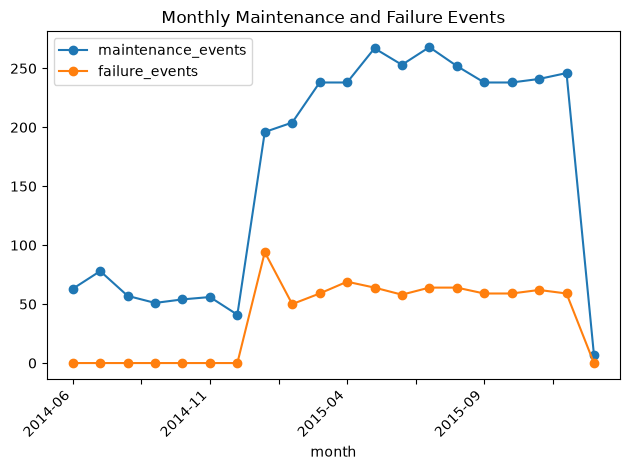

,maintenance_events,failure_events
month,,
2014-06,63,0.0
2014-07,78,0.0
2014-08,57,0.0
2014-09,51,0.0
2014-10,54,0.0
2014-11,56,0.0
2014-12,41,0.0
2015-01,196,94.0
2015-02,204,50.0


In [9]:
maintenance["month"] = maintenance["datetime"].dt.to_period("M").astype(str)
failures["month"] = failures["datetime"].dt.to_period("M").astype(str)
monthly = pd.concat([maintenance.groupby("month").size().rename("maintenance_events"), failures.groupby("month").size().rename("failure_events")], axis=1).fillna(0)
monthly.plot(marker="o", title="Monthly Maintenance and Failure Events")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
display(monthly)


## 8. Recorded intervals between failures
This is a descriptive interval between recorded failures, **not true MTBF**, because the dataset does not provide an operating-hours denominator for each machine.


In [10]:
f = failures.sort_values(["machineID","datetime"]).copy()
f["previous_failure"] = f.groupby("machineID")["datetime"].shift()
f["days_between"] = (f["datetime"] - f["previous_failure"]).dt.total_seconds()/86400
display(f.groupby("machineID")["days_between"].mean().dropna().sort_values().head(15))


machineID
99    19.229167
98    20.000000
93    21.000000
13    21.250000
71    22.500000
27    22.500000
22    22.866071
17    25.651786
35    25.912500
37    26.538462
49    27.272727
16    27.510417
83    27.625000
20    30.000000
73    30.011364
Name: days_between, dtype: float64

## 9. Business interpretation checklist
After running the notebook, write conclusions using measured values only. Recommended structure: **observation -> operational meaning -> recommended next investigation/action**. Avoid claiming causality from correlation, and avoid calling the recorded failure interval MTBF.
